In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("csv_result-KDDTest+.csv")

print(df.head())
print(df.shape)

   id  'duration' 'protocol_type' 'service' 'flag'  'src_bytes'  'dst_bytes'  \
0   1           0             tcp   private    REJ            0            0   
1   2           0             tcp   private    REJ            0            0   
2   3           2             tcp  ftp_data     SF        12983            0   
3   4           0            icmp     eco_i     SF           20            0   
4   5           1             tcp    telnet   RSTO            0           15   

   'land'  'wrong_fragment'  'urgent'  ...  'dst_host_srv_count'  \
0       0                 0         0  ...                    10   
1       0                 0         0  ...                     1   
2       0                 0         0  ...                    86   
3       0                 0         0  ...                    57   
4       0                 0         0  ...                    86   

   'dst_host_same_srv_rate'  'dst_host_diff_srv_rate'  \
0                      0.04                      0.06

In [3]:
df.columns = df.columns.str.replace("'", "")

In [4]:
print(df.columns)

Index(['id', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')


In [5]:
df

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,1,0,tcp,private,REJ,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,anomaly
1,2,0,tcp,private,REJ,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,anomaly
2,3,2,tcp,ftp_data,SF,12983,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal
3,4,0,icmp,eco_i,SF,20,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,anomaly
4,5,1,tcp,telnet,RSTO,0,15,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,22540,0,tcp,smtp,SF,794,333,0,0,0,...,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal
22540,22541,0,tcp,http,SF,317,938,0,0,0,...,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal
22541,22542,0,tcp,http,SF,54540,8314,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,anomaly
22542,22543,0,udp,domain_u,SF,42,42,0,0,0,...,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal


In [6]:
df = df.drop("id", axis=1)

In [7]:
print(df["class"].value_counts())

class
anomaly    12833
normal      9711
Name: count, dtype: int64


In [8]:
X = df.drop("class", axis=1)
y = df["class"]

In [9]:
X = pd.get_dummies(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9862497227766689


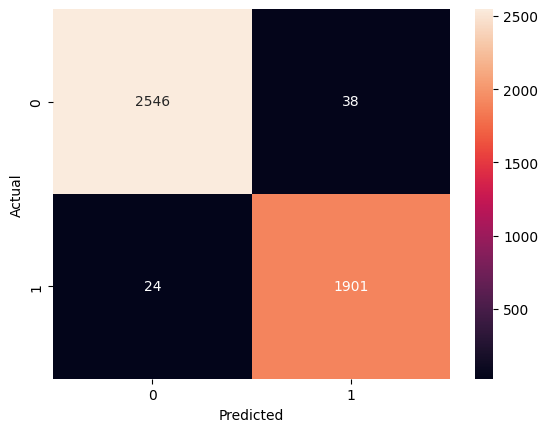

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     anomaly       0.99      0.99      0.99      2584
      normal       0.98      0.99      0.98      1925

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509



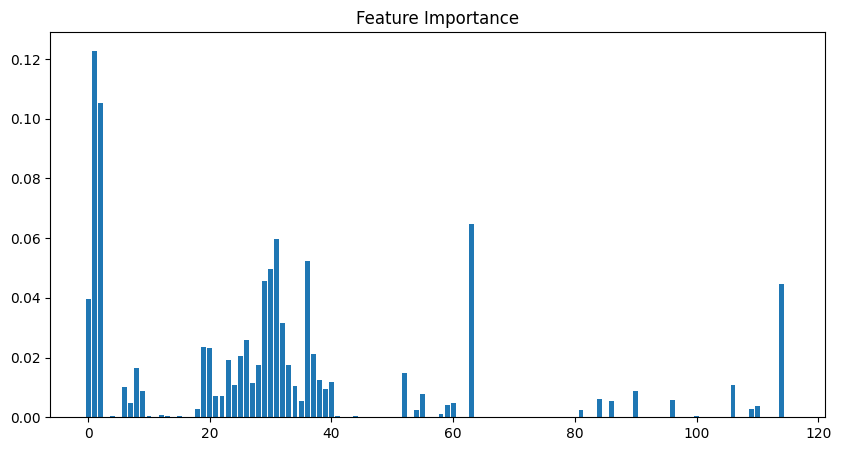

In [16]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [17]:
for i in range(5):
    sample = X.iloc[i:i+1]
    pred = model.predict(sample)[0]
    
    print("Row:", i)
    print("Actual:", y.iloc[i])
    print("Predicted:", pred)
    print()

Row: 0
Actual: anomaly
Predicted: anomaly

Row: 1
Actual: anomaly
Predicted: anomaly

Row: 2
Actual: normal
Predicted: normal

Row: 3
Actual: anomaly
Predicted: anomaly

Row: 4
Actual: anomaly
Predicted: anomaly



In [18]:
row = int(input("Enter row number to predict: "))

if 0 <= row < len(X):
    sample = X.iloc[row:row+1]
    prediction = model.predict(sample)

    print("\n--- RESULT ---")
    print("Row Number:", row)

    if prediction[0] == "normal":
        print("Prediction: NORMAL ✅")
    else:
        print("Prediction: ANOMALY ⚠️")

    print("Actual:", y.iloc[row])

else:
    print("Row number out of range")

Enter row number to predict:  232



--- RESULT ---
Row Number: 232
Prediction: ANOMALY ⚠️
Actual: anomaly


In [20]:
import pickle

pickle.dump(model, open("cyber_model.pkl", "wb"))